In [1]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
import ipywidgets as widget
from XRootD import client
import os
import tqdm
import xsec

Welcome to JupyROOT 6.28/06


## Choose parameters

In [2]:
year = widget.Dropdown( options = [ "2016APV", "2016", "2017", "2018" ], value = "2017" )
year

Dropdown(index=2, options=('2016APV', '2016', '2017', '2018'), value='2017')

In [3]:
lumitext = {
    "2016APV": "($19.52\ \mathrm{fb^{-1}}$)",
    "2016": "($16.81\ \mathrm{fb^{-1}}$)",
    "2017": "($41.48\ \mathrm{fb^{-1}}$)",
    "2018": "($59.83\ \mathrm{fb^{-1}}$)"
}

In [4]:
bruxPrefix = "root://brux30.hep.brown.edu:1094/"
step2Dir = "/store/user/dali/FWLJMET106XUL_singleLep{}UL_RunIISummer20_3t_step1hadds/nominal/".format( year.value )
xrdClient = client.FileSystem( bruxPrefix )
status, dirList = xrdClient.dirlist( step2Dir )
samples = [ item.name for item in dirList ]

In [5]:
setA = widget.SelectMultiple( options = samples, value = [ sample for sample in samples if "TTToSemiLeptonic" in sample and "HT500" in sample ] )
setA

SelectMultiple(index=(53, 54, 55, 56, 57), options=('DYJetsToLL_M-50_HT-1200to2500_TuneCP5_PSweights_13TeV-mad…

In [6]:
print( "Including samples into set A:" )
for sample_ in setA.value:
    print( "  + {}".format( sample_ ) )

Including samples into set A:
  + TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT500Njet9_tt1b_hadd.root
  + TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT500Njet9_tt2b_hadd.root
  + TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT500Njet9_ttbb_hadd.root
  + TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT500Njet9_ttcc_hadd.root
  + TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT500Njet9_ttjj_hadd.root


In [7]:
setB = widget.SelectMultiple( options = samples, value = [ sample for sample in samples if "TTToSemiLepton_HT500" in sample ] )
setB

SelectMultiple(index=(34, 35, 36, 37, 38), options=('DYJetsToLL_M-50_HT-1200to2500_TuneCP5_PSweights_13TeV-mad…

In [8]:
print( "Including samples into set B:" )
for sample_ in setB.value:
    print( "  + {}".format( sample_ ) )

Including samples into set B:
  + TTToSemiLepton_HT500Njet9_TuneCP5_13TeV-powheg-pythia8_tt1b_hadd.root
  + TTToSemiLepton_HT500Njet9_TuneCP5_13TeV-powheg-pythia8_tt2b_hadd.root
  + TTToSemiLepton_HT500Njet9_TuneCP5_13TeV-powheg-pythia8_ttbb_hadd.root
  + TTToSemiLepton_HT500Njet9_TuneCP5_13TeV-powheg-pythia8_ttcc_hadd.root
  + TTToSemiLepton_HT500Njet9_TuneCP5_13TeV-powheg-pythia8_ttjj_hadd.root


In [9]:
nJ_region = widget.IntRangeSlider( min = 4, max = 12, value = [4,10], step = 1 )
nJ_region

IntRangeSlider(value=(4, 10), max=12, min=4)

In [12]:
nB_region = widget.IntRangeSlider( min = 1, max = 6, value = [1,3], step = 1 )
nB_region

IntRangeSlider(value=(1, 3), max=6, min=1)

## Parse through the dataset

In [13]:
nJ_min = nJ_region.value[0]
nJ_max = nJ_region.value[1]
nJ_bins = np.linspace( nJ_min, nJ_max, nJ_max - nJ_min + 1 ).astype(int)
nB_min = nB_region.value[0]
nB_max = nB_region.value[1]
nB_bins = np.linspace( nB_min, nB_max, nB_max - nB_min + 1 ).astype(int)
ht = {}
for category in [ "A", "B" ]:
    ht[category] = {}
    for nJ in nJ_bins:
        ht[category][nJ] = {}
        for nB in nB_bins:
            ht[category][nJ][nB] = np.array([])

Parse through samples in set A

In [14]:
for sample in tqdm.tqdm( setA.value ):
    rDF = ROOT.RDataFrame( "ljmet", bruxPrefix + step2Dir + sample )
    for nJ in nJ_bins:
        for nB in nB_bins:
            sign_nJ = ">=" if nJ == nJ_max else "=="
            sign_nB = ">=" if nB == nB_max else "=="
            rDF_nBnJ = rDF.Filter( "NJets_JetSubCalc {} {} && NJetsCSV_JetSubCalc {} {}".format( sign_nJ, nJ, sign_nB, nB ) )
            ht["A"][nJ][nB] = np.append( ht["A"][nJ][nB], rDF_nBnJ.AsNumpy( columns = [ "AK4HT" ] )[ "AK4HT" ] )
            del rDF_nBnJ
    del rDF

100%|██████████| 5/5 [02:55<00:00, 35.19s/it]


Parse through samples in set B

In [15]:
for sample in tqdm.tqdm( setB.value ):
    rDF = ROOT.RDataFrame( "ljmet", bruxPrefix + step2Dir + sample )
    for nJ in nJ_bins:
        for nB in nB_bins:
            sign_nJ = ">=" if nJ == nJ_max else "=="
            sign_nB = ">=" if nB == nB_max else "=="
            rDF_nBnJ = rDF.Filter( "NJets_JetSubCalc {} {} && NJetsCSV_JetSubCalc {} {}".format( sign_nJ, nJ, sign_nB, nB ) )
            ht["B"][nJ][nB] = np.append( ht["B"][nJ][nB], rDF_nBnJ.AsNumpy( columns = [ "AK4HT" ] )[ "AK4HT" ] )
            del rDF_nBnJ
    del rDF

100%|██████████| 5/5 [02:22<00:00, 28.55s/it]


## Plot the various regions in $N_j$ and $N_b$ space

Plot parameters

In [16]:
bins = np.linspace( 0, 4000, 41 )

First, plot the inclusive region

In [17]:
hist_incl_A = np.concatenate( [ ht["A"][nJ][nB] for nJ in nJ_bins for nB in nB_bins ] )
hist_incl_B = np.concatenate( [ ht["B"][nJ][nB] for nJ in nJ_bins for nB in nB_bins ] )

/tmp/ipykernel_5794/907390947.py:13: RuntimeWarning: invalid value encountered in divide
  scaleA = histNorm_A[0] / hist_A[0]
/tmp/ipykernel_5794/907390947.py:21: RuntimeWarning: invalid value encountered in divide
  scaleB = histNorm_B[0] / hist_B[0]


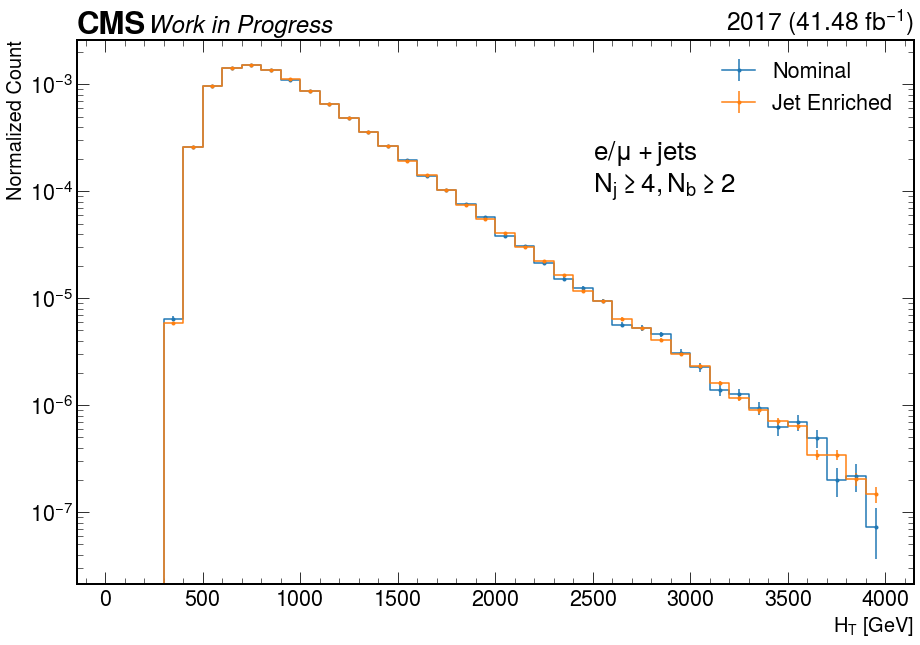

In [19]:
plt.style.use( hep.style.CMS )
plt.figure( figsize = (15,10) )

hep.cms.text( "Work in Progress", fontsize = 24 )
hep.cms.lumitext( "{} {}".format( year.value, lumitext[ year.value ] ) )

hist_A = np.histogram(
    hist_incl_A, bins = bins
)
histNorm_A = np.histogram(
    hist_incl_A, bins = bins, density = True
)
scaleA = histNorm_A[0] / hist_A[0]

hist_B = np.histogram(
    hist_incl_B, bins = bins
)
histNorm_B = np.histogram(
    hist_incl_B, bins = bins, density = True
)
scaleB = histNorm_B[0] / hist_B[0]

plt.errorbar(
    0.5 * ( histNorm_A[1][1:] + histNorm_A[1][:-1] ),
    histNorm_A[0],
    yerr = np.sqrt( hist_A[0] ) * scaleA,
    marker = ".", drawstyle = "steps-mid", label = "Nominal"
)

plt.errorbar(
    0.5 * ( histNorm_B[1][1:] + histNorm_B[1][:-1] ),
    histNorm_B[0],
    yerr = np.sqrt( hist_B[0] ) * scaleB,
    marker = ".", drawstyle = "steps-mid", label = "Jet Enriched"
)


plt.text( 2500, 2e-4, "$e/\mu+\mathrm{jets}$" )
plt.text( 2500, 1e-4, "$N_j\geq{4},N_b\geq{2}$" )
plt.xlabel( "$H_T\ [\mathrm{GeV}]$", x = 1.0, ha = "right", fontsize = 20 )
plt.ylabel( "Normalized Count", y = 1.0, ha = "right", fontsize = 20 )

plt.yscale( "log" )
plt.legend( loc = "best" )

plt.show()
plt.close()

Plot the binned histograms

/tmp/ipykernel_5794/4130607748.py:12: RuntimeWarning: invalid value encountered in divide
  scaleA = hist_A[0] / histNorm_A[0]
/tmp/ipykernel_5794/4130607748.py:21: RuntimeWarning: invalid value encountered in divide
  scaleB = hist_B[0] / histNorm_B[0]


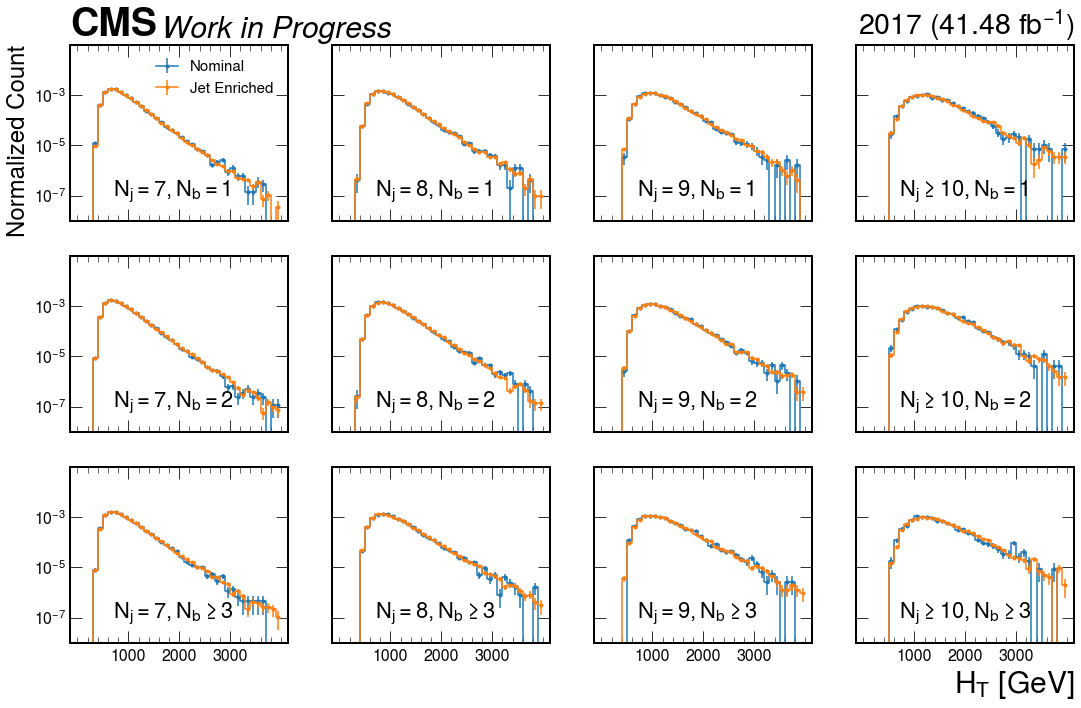

In [25]:
plt.style.use( hep.style.CMS )
fig, subplots = plt.subplots( len(nB_bins), len(nJ_bins), figsize = ( 18, 11 ) )

for i, nB in enumerate( nB_bins ):
    for j, nJ in enumerate( nJ_bins ):
        hist_A = np.histogram(
            ht["A"][nJ][nB], bins = bins
        )
        histNorm_A = np.histogram(
            ht["A"][nJ][nB], bins = bins, density = True
        )
        scaleA = hist_A[0] / histNorm_A[0]

        hist_B = np.histogram(
            ht["B"][nJ][nB], bins = bins
        )
        histNorm_B = np.histogram(
            ht["B"][nJ][nB], bins = bins, density = True
        )
        
        scaleB = hist_B[0] / histNorm_B[0]

        subplots[i][j].errorbar(
            0.5 * ( histNorm_A[1][1:] + histNorm_A[1][:-1] ),
            histNorm_A[0],
            yerr = np.sqrt( hist_A[0] ) / scaleA,
            marker = ".", drawstyle = "steps-mid", label = "Nominal"
        )

        subplots[i][j].errorbar(
            0.5 * ( histNorm_B[1][1:] + histNorm_B[1][:-1] ),
            histNorm_B[0],
            yerr = np.sqrt( hist_B[0] ) / scaleB,
            marker = ".", drawstyle = "steps-mid", label = "Jet Enriched"
        )
        
        subplots[i][j].set_ylim( 1e-8, 1e-1 )
        subplots[i][j].set_yscale( "log" )
        if nJ != min(nJ_bins):
            subplots[i][j].set_yticks([1e-7,1e-5,1e-3])
            subplots[i][j].set_yticklabels([])
        else:
            subplots[i][j].set_yticks([1e-7,1e-5,1e-3])
            subplots[i][j].set_yticklabels(["$10^{-7}$","$10^{-5}$","$10^{-3}$"],fontsize=16)
        if nB != max(nB_bins):
            subplots[i][j].set_xticks([1000,2000,3000])
            subplots[i][j].set_xticklabels([])
        else:
            subplots[i][j].set_xticks([1000,2000,3000])
            subplots[i][j].set_xticklabels([1000,2000,3000],fontsize=16)
        
        nJ_eq = "\geq" if nJ == max(nJ_bins) else "="
        nB_eq = "\geq" if nB == max(nB_bins) else "="
        subplots[i][j].text( 700, 1e-7, "$N_j{}{},N_b{}{}$".format( nJ_eq, nJ, nB_eq, nB ), fontsize = 22 )
        if nJ == max(nJ_bins) and nB == max(nB_bins):
            subplots[i][j].set_xlabel( "$H_T\ [\mathrm{GeV}]$", x = 1.0, ha = "right", fontsize = 30 )
        if nJ == min(nJ_bins) and nB == min(nB_bins):
            subplots[i][j].set_ylabel( "Normalized Count", y = 1.0, ha = "right", fontsize = 24 )
            subplots[i][j].legend( loc = "best", fontsize = 15 )


hep.cms.text( "Work in Progress", ax = subplots[0][0], fontsize = 30 )
hep.cms.lumitext( "{} {}".format( year.value, lumitext[ year.value ] ), ax = subplots[0][len(nJ_bins)-1], fontsize = 30 )
            
#plt.tight_layout()
plt.show()
plt.close()